# AI MetroFlow - Exploratory Data Analysis

## Dataset: Delhi Metro Network

### Project
AI MetroFlow: AI Platform for Metro Crowd Management and Scheduling

### Objective
To analyze the Delhi Metro Network dataset, understand station connectivity, metro lines, and station attributes that will support route planning and crowd management.

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

In [3]:
df = pd.read_csv("../../datasets/Delhi-Metro-Network.csv")

In [4]:
df.head()

,Station ID,Station Name,Distance from Start (km),Line,Opening Date,Station Layout,Latitude,Longitude
0,1,Jhil Mil,10.3,Red line,2008-04-06,Elevated,28.675790,77.312390
1,2,Welcome [Conn: Red],46.8,Pink line,2018-10-31,Elevated,28.671800,77.277560
2,3,DLF Phase 3,10.0,Rapid Metro,2013-11-14,Elevated,28.493600,77.093500
3,4,Okhla NSIC,23.8,Magenta line,2017-12-25,Elevated,28.554483,77.264849
4,5,Dwarka Mor,10.2,Blue line,2005-12-30,Elevated,28.619320,77.033260


In [5]:
df.shape


(285, 8)

In [6]:
df.columns.tolist()

['Station ID',
 'Station Name',
 'Distance from Start (km)',
 'Line',
 'Opening Date',
 'Station Layout',
 'Latitude',
 'Longitude']

In [7]:
df.isnull().sum()

Station ID                  0
Station Name                0
Distance from Start (km)    0
Line                        0
Opening Date                0
Station Layout              0
Latitude                    0
Longitude                   0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.dtypes

Station ID                    int64
Station Name                 object
Distance from Start (km)    float64
Line                         object
Opening Date                 object
Station Layout               object
Latitude                    float64
Longitude                   float64
dtype: object

In [10]:
df["Station Layout"].value_counts()

Station Layout
Elevated       214
Underground     68
At-Grade         3
Name: count, dtype: int64

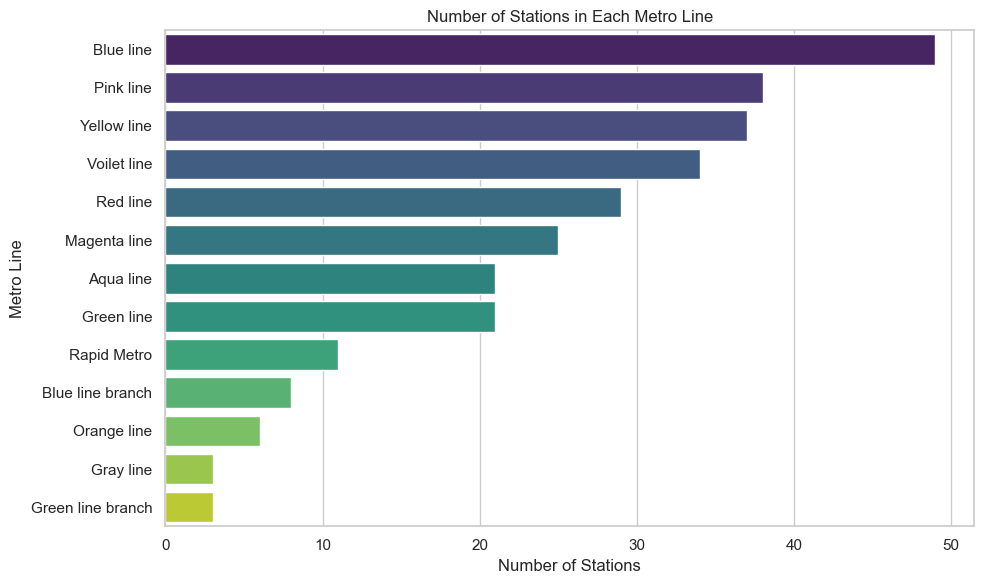

In [16]:
plt.figure(figsize=(10,6))

line_counts = df["Line"].value_counts()

sns.barplot(
    x=line_counts.values,
    y=line_counts.index,
    hue=line_counts.index,
    palette="viridis",
    legend=False
)

plt.title("Number of Stations in Each Metro Line")
plt.xlabel("Number of Stations")
plt.ylabel("Metro Line")

plt.tight_layout()
plt.show()

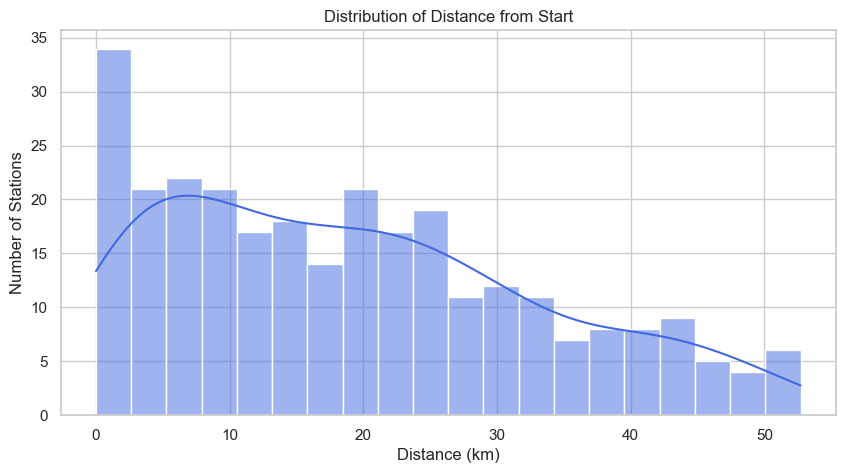

In [17]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x="Distance from Start (km)",
    bins=20,
    kde=True,
    color="royalblue"
)

plt.title("Distribution of Distance from Start")
plt.xlabel("Distance (km)")
plt.ylabel("Number of Stations")

plt.show()

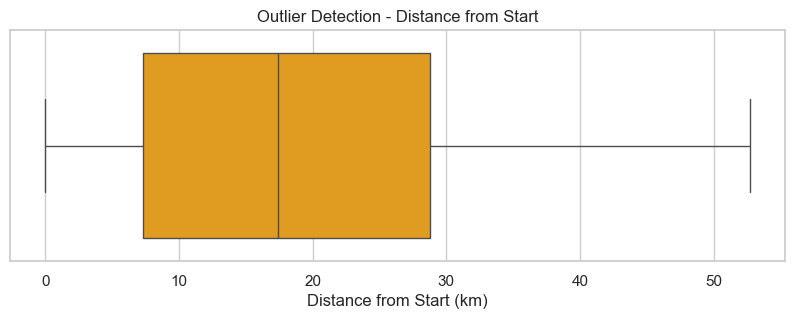

In [18]:
plt.figure(figsize=(10,3))

sns.boxplot(
    x=df["Distance from Start (km)"],
    color="orange"
)

plt.title("Outlier Detection - Distance from Start")

plt.show()

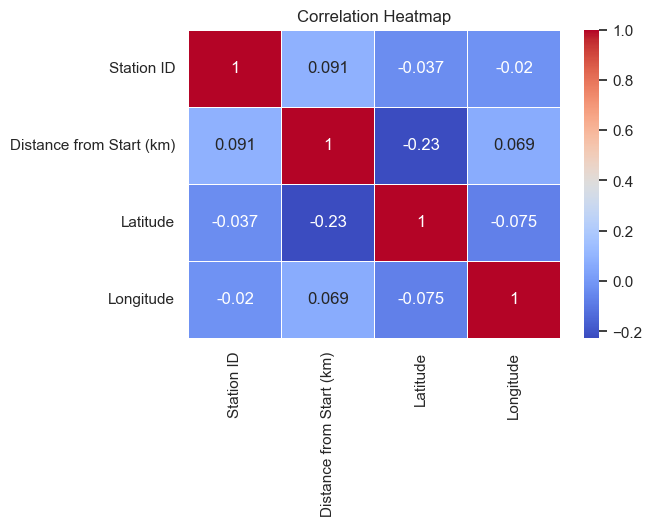

In [19]:
plt.figure(figsize=(6,4))

sns.heatmap(
    df.select_dtypes(include="number").corr(),
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.show()

In [20]:
df["Opening Date"] = pd.to_datetime(df["Opening Date"])

df["Opening Year"] = df["Opening Date"].dt.year

df.head()

,Station ID,Station Name,Distance from Start (km),Line,Opening Date,Station Layout,Latitude,Longitude,Opening Year
0,1,Jhil Mil,10.3,Red line,2008-04-06,Elevated,28.675790,77.312390,2008
1,2,Welcome [Conn: Red],46.8,Pink line,2018-10-31,Elevated,28.671800,77.277560,2018
2,3,DLF Phase 3,10.0,Rapid Metro,2013-11-14,Elevated,28.493600,77.093500,2013
3,4,Okhla NSIC,23.8,Magenta line,2017-12-25,Elevated,28.554483,77.264849,2017
4,5,Dwarka Mor,10.2,Blue line,2005-12-30,Elevated,28.619320,77.033260,2005


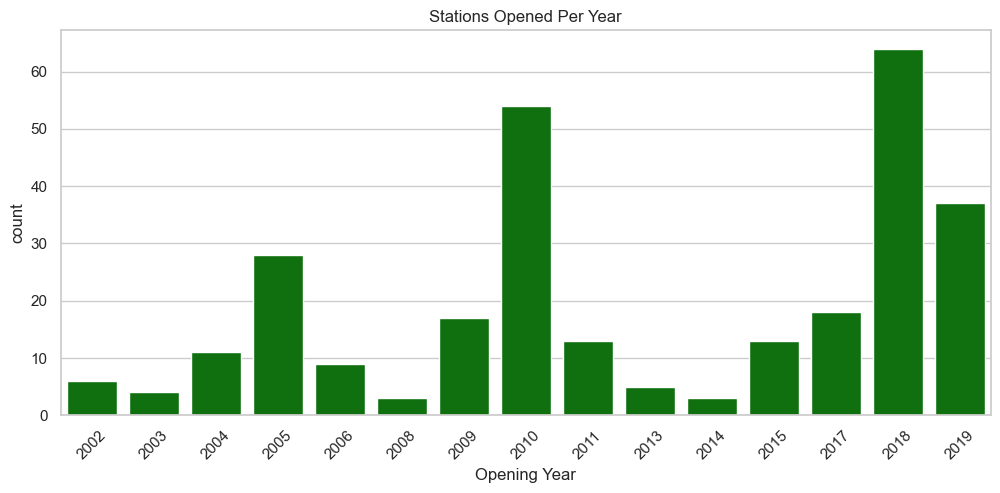

In [21]:
plt.figure(figsize=(12,5))

sns.countplot(
    data=df,
    x="Opening Year",
    order=sorted(df["Opening Year"].unique()),
    color="green"
)

plt.xticks(rotation=45)

plt.title("Stations Opened Per Year")

plt.show()

In [22]:
df.groupby("Line")["Distance from Start (km)"].mean().sort_values(ascending=False)

Line
Pink line            28.773684
Blue line            26.144898
Yellow line          21.462162
Voilet line          20.617647
Magenta line         17.656000
Red line             16.558621
Aqua line            13.352381
Green line           11.380952
Orange line          10.566667
Rapid Metro           5.709091
Blue line branch      4.000000
Gray line             1.800000
Green line branch     1.066667
Name: Distance from Start (km), dtype: float64

In [23]:
df.sort_values(
    "Distance from Start (km)",
    ascending=False
)[["Station Name","Line","Distance from Start (km)"]].head(10)

,Station Name,Line,Distance from Start (km)
74,Noida Sector 62,Blue line,52.7
30,Shiv Vihar,Pink line,52.6
160,Johri Enclave,Pink line,51.7
71,Noida Sector 59,Blue line,51.5
88,Noida Sector 61,Blue line,50.5
266,Gokulpuri,Pink line,50.4
77,Noida Sector 52 [Conn: Aqua],Blue line,49.3
103,Maujpur,Pink line,49.1
234,Noida Sector 34,Blue line,48.1
173,Jaffrabad,Pink line,48.0


In [24]:
df.to_csv(
    "../cleaned_data/delhi_metro_network_clean.csv",
    index=False
)

print("Delhi Metro Network cleaned dataset saved successfully!")

Delhi Metro Network cleaned dataset saved successfully!


# EDA Summary

## Key Insights

- Checked dataset structure and data types.
- Verified missing values and duplicates.
- Analyzed metro line distribution.
- Explored station layout categories.
- Studied distance distribution and detected outliers.
- Created correlation heatmap.
- Analyzed metro network expansion using opening year.
- Generated cleaned dataset for backend integration.

## Conclusion

This dataset will be used for:

- Metro route visualization
- Route recommendation
- Station information APIs
- AI-based route optimization
- Interactive map integration